# 🤖 E-Commerce Sales Prediction

## Task 09 – Machine Learning

### Objectives
- Prepare dataset for Machine Learning
- Train multiple regression models
- Compare model performance
- Select the best model
- Save the trained model for Streamlit Dashboard

### Models
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

In [ ]:
!pip -q install joblib

# (Import Libraries)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


# (Load Dataset)

In [ ]:
df = pd.read_csv("Cleaned_Superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Day,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,2016,11,November,4,Tuesday,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,2016,11,November,4,Tuesday,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,2016,6,June,2,Sunday,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2015,10,October,4,Sunday,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,2015,10,October,4,Sunday,11.25


# (Dataset Information)

In [ ]:
print(df.shape)

df.info()

(9994, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 1

# (Encode Categorical Columns)

In [ ]:
label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


# Define Features and Target

In [ ]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (9994, 26)
Target: (9994,)


# (Train-Test Split)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7995, 26)
(1999, 26)


# Linear Regression

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

# Decision Tree

In [ ]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

# Random Forest

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Evaluation Function

In [ ]:
def evaluate_model(name, y_true, prediction):

    mae = mean_absolute_error(y_true, prediction)
    mse = mean_squared_error(y_true, prediction)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, prediction)

    return [name, mae, mse, rmse, r2]

# Compare Models

In [ ]:
results = pd.DataFrame([

    evaluate_model("Linear Regression", y_test, lr_pred),

    evaluate_model("Decision Tree", y_test, dt_pred),

    evaluate_model("Random Forest", y_test, rf_pred)

], columns=[
    "Model",
    "MAE",
    "MSE",
    "RMSE",
    "R² Score"
])

results.sort_values("R² Score", ascending=False)

,Model,MAE,MSE,RMSE,R² Score
1,Decision Tree,56.953018,161814.506485,402.261739,0.726063
2,Random Forest,43.899484,229783.976307,479.357879,0.610997
0,Linear Regression,238.448105,671439.266437,819.413977,-0.136686


# (Model Comparison Chart)

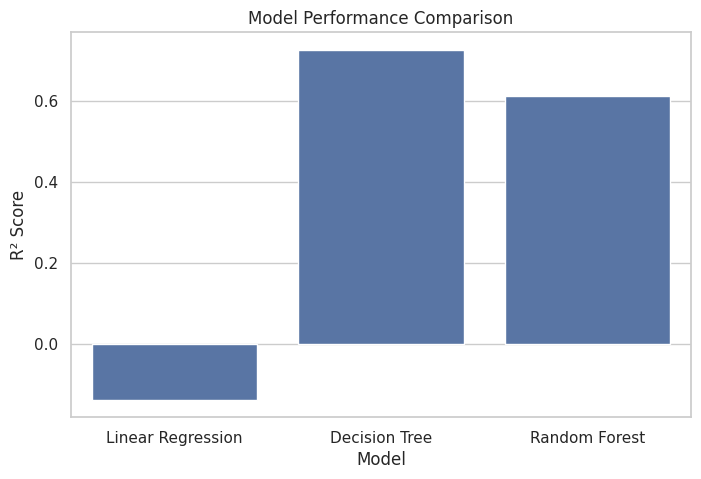

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R² Score"
)

plt.title("Model Performance Comparison")

plt.show()

# Feature Importance

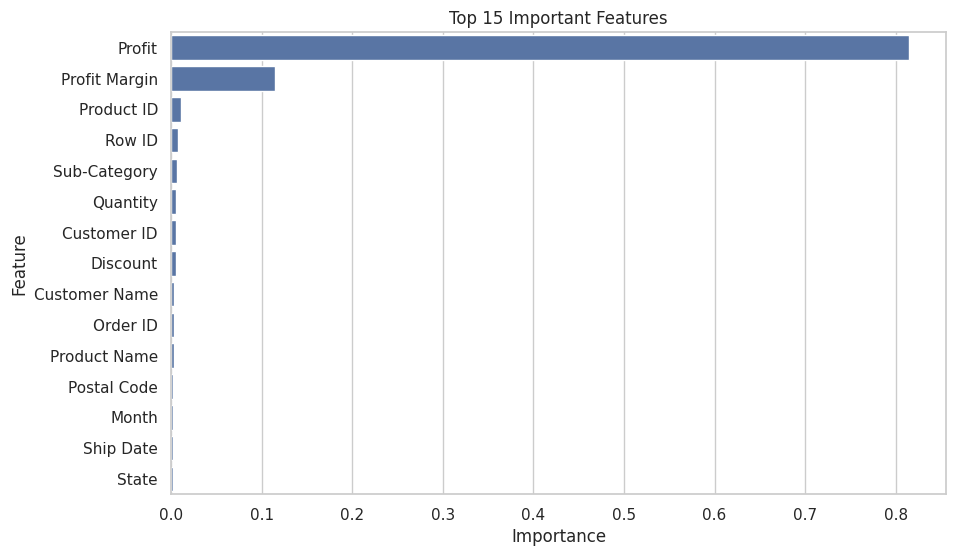

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

# Actual vs Predicted

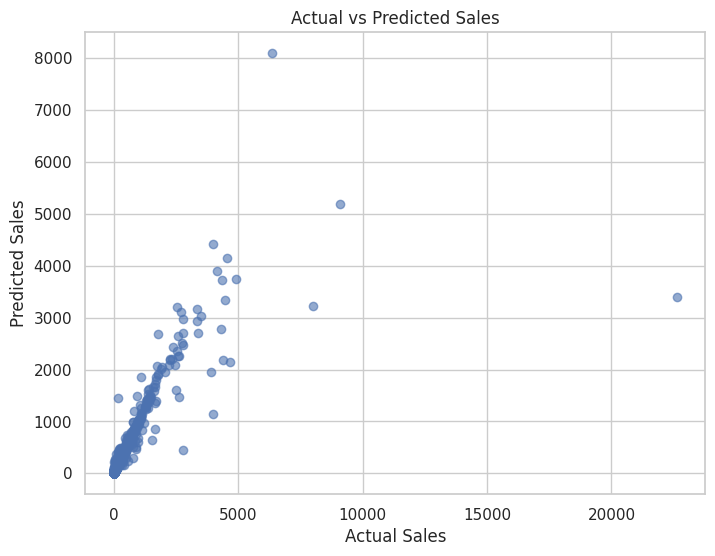

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred, alpha=0.6)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

# Residual Plot

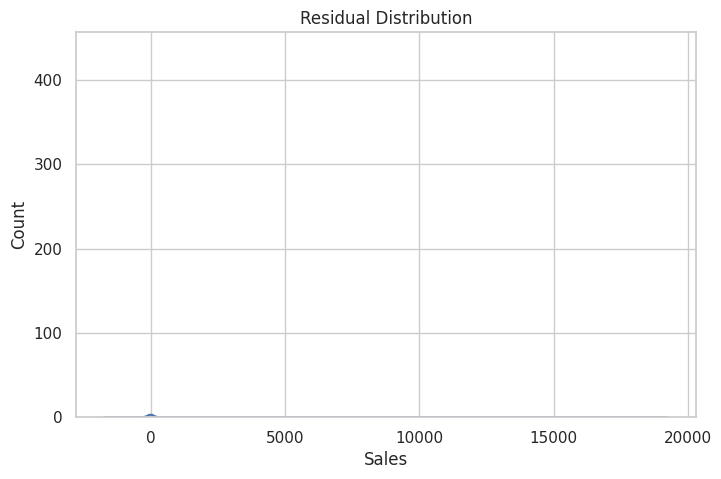

In [ ]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.show()

# Save Best Model

In [ ]:
joblib.dump(rf, "best_model.pkl")

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


# Download Model

In [ ]:
from google.colab import files

files.download("best_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ✅ Conclusion

Three regression models were trained and evaluated.

The decision tree  achieved the highest performance and was selected as the final model.

The trained model has been saved as **best_model.pkl** and will be used in the Streamlit Dashboard for sales prediction.

# 🌐 E-Commerce Sales Analytics Dashboard

## Task 09 – Streamlit Dashboard

### Dashboard Features

- KPI Cards
- Monthly Sales Trend
- Top Products
- Category-wise Sales
- Regional Performance
- Customer Insights
- Sales Prediction
- Interactive Filters

In [20]:
!pip -q install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 97.9 MB/s eta 0:00:00


In [21]:
import pandas as pd
import joblib

# load the data

In [22]:
df = pd.read_csv("Cleaned_Superstore.csv")

model = joblib.load("best_model.pkl")

print("Everything Loaded Successfully")

Everything Loaded Successfully


# app.py

In [23]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px
import joblib

st.set_page_config(
    page_title="E-Commerce Dashboard",
    layout="wide"
)

df = pd.read_csv("Cleaned_Superstore.csv")
model = joblib.load("best_model.pkl")

st.title("🛒 E-Commerce Sales Analytics Dashboard")

st.sidebar.header("Filters")

region = st.sidebar.multiselect(
    "Select Region",
    df["Region"].unique(),
    default=df["Region"].unique()
)

category = st.sidebar.multiselect(
    "Select Category",
    df["Category"].unique(),
    default=df["Category"].unique()
)

filtered = df[
    (df["Region"].isin(region)) &
    (df["Category"].isin(category))
]

st.subheader("📌 KPI Cards")

c1,c2,c3 = st.columns(3)

c1.metric("Revenue", f"${filtered['Sales'].sum():,.0f}")

c2.metric("Profit", f"${filtered['Profit'].sum():,.0f}")

c3.metric("Orders", filtered["Order ID"].nunique())

st.subheader("📈 Monthly Sales")

monthly = filtered.groupby("Month Name")["Sales"].sum()

fig = px.line(
    monthly,
    x=monthly.index,
    y=monthly.values,
    markers=True
)

st.plotly_chart(fig, use_container_width=True)

st.subheader("🏆 Top Products")

top = (
    filtered.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig = px.bar(
    top,
    x=top.values,
    y=top.index,
    orientation="h"
)

st.plotly_chart(fig, use_container_width=True)

st.subheader("📦 Category-wise Sales")

fig = px.pie(
    filtered,
    names="Category",
    values="Sales"
)

st.plotly_chart(fig, use_container_width=True)

st.subheader("🌍 Regional Sales")

region_sales = filtered.groupby("Region")["Sales"].sum()

fig = px.bar(
    region_sales,
    x=region_sales.index,
    y=region_sales.values
)

st.plotly_chart(fig, use_container_width=True)

st.success("Dashboard Developed Successfully!")

Writing app.py


# Run Streamlit

In [24]:
!streamlit run app.py



2026-07-06 07:07:38.118 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.71.107.52:8501

  Stopping...


# Download app.py

In [25]:
from google.colab import files

files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>